In [1]:
# first attempt in implementing logistic regression for multiple features
# let's go !!

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/dileep070/heart-disease-prediction-using-logistic-regression/framingham.csv")
df = df.dropna()

x_df = df.drop(columns=['TenYearCHD'])
y_df = df['TenYearCHD']
x_np = x_df.to_numpy()
y_np = y_df.to_numpy()

#feature scaling is fatal when the peak to peak ranges are too wide
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm

x_np_scaled = zscore_normalize_features(x_np)
#there are over 4000 examples, for this i will us 200 for training
x_train = x_np_scaled[:200, :]
y_train = y_np[:200]

In [2]:
def sigmoid(z):
    gg = 1 / (1 + np.exp(-z))
    return gg

def model(x: np.array, w: np.array, b: float):
    return sigmoid(np.dot(x, w) + b)

def logistic_loss(x_i: np.array, y_i, w: np.array, b: float):
    """
    x_i: vector for the i^th example in the loop of cost function
    y_i: i^th output/target
    returns the loss of i^th example
    """
    loss = -y_i*np.log(model(x_i,w,b)) - (1-y_i)*np.log(1-model(x_i,w,b))
    return loss

def logistic_cost(x: np.array, y: np.array, w: np.array, b):
    m = x.shape[0]
    total_cost = 0
    for i in range(m):
        total_cost += logistic_loss(x[i], y[i], w, b)
    return total_cost / m


def get_grads(x: np.array, y: np.array, w: np.array, b):
    """
    returns dj_dw: a vector of all gradients with respect to each w_j
            dj_db: a scalar of gradient with respect to b
    """
    m,n = x.shape
    dj_dw = np.zeros((n,))
    dj_db = 0
    for i in range(m):
        err_i = model(x[i], w, b) - y[i]
        dj_dw +=x[i] * err_i
        dj_db += err_i
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

def gradient_descent(x: np.array, y: np.array, w: np.array, b, alpha, num_iters):
    J_hist = []
    current_J = 0

    for i in range(num_iters):
        dw, db = get_grads(x, y, w, b)
        w = w - alpha * dw  #thx to numpy's built-in broadcasting, this is supposed to work fine 
        b -= alpha * db
        if i % (num_iters // 10) == 0:
            current_J = logistic_cost(x, y, w, b)
            J_hist.append(current_J)
            print(f"iteration: {i:5d} | current cost: {current_J:.4f}")
    return w, b, J_hist

In [3]:
initial_w = np.zeros(x_train.shape[1])
initial_b = 0.0
iters = 1000

w_out, b_out, J_hist = gradient_descent(
    x_train, 
    y_train, 
    initial_w, 
    initial_b, 
    alpha=0.1, 
    num_iters=iters)
print(f"found w= {w_out} found b= {b_out:.4f} | final cost: {J_hist[-1]} ")

iteration:     0 | current cost: 0.6799
iteration:   100 | current cost: 0.4344
iteration:   200 | current cost: 0.4211
iteration:   300 | current cost: 0.4179
iteration:   400 | current cost: 0.4167
iteration:   500 | current cost: 0.4161
iteration:   600 | current cost: 0.4157
iteration:   700 | current cost: 0.4155
iteration:   800 | current cost: 0.4153
iteration:   900 | current cost: 0.4152
found w= [ 0.2444968   0.41299081  0.19306254 -0.44112385  0.54162036 -0.1533996
  0.13313971  0.11498441 -0.12926796  0.53330247  0.07097274  0.31890096
  0.05817467 -0.38947332  0.21103781] found b= -1.7517 | final cost: 0.4152407807211984 


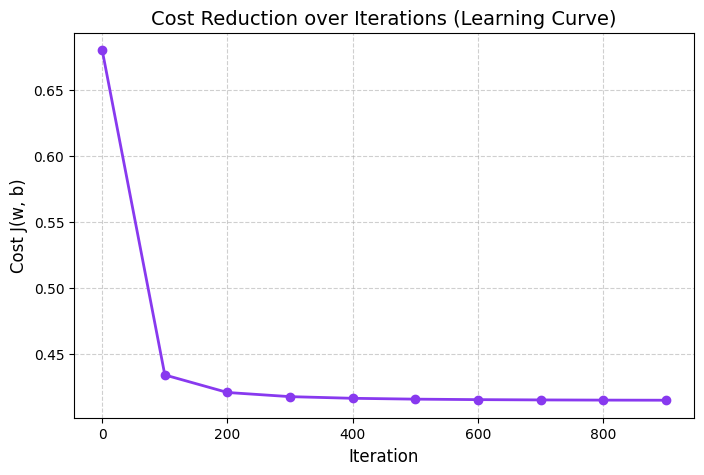

In [4]:
import math
plt.figure(figsize=(8, 5))
plt.plot(range(0, iters, math.ceil(iters/10)), J_hist, color='#8839ef', marker='o', linewidth=2)
plt.title("Cost Reduction over Iterations (Learning Curve)", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost J(w, b)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

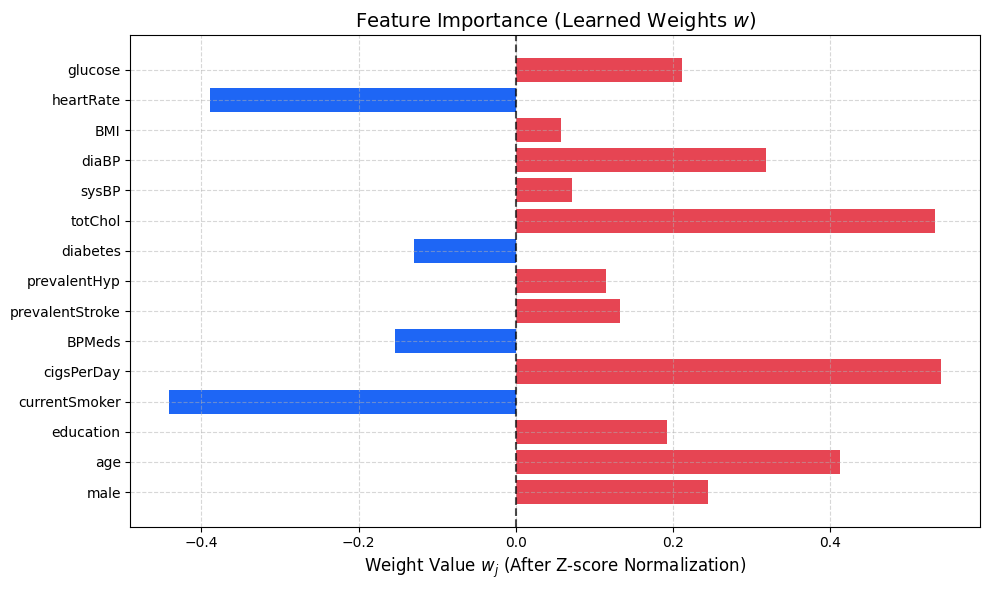

In [5]:
# Feature Importance Bar Chart
feature_names = x_df.columns

plt.figure(figsize=(10, 6))
colors = ['#e64553' if w > 0 else '#1e66f5' for w in w_out]
plt.barh(feature_names, w_out, color=colors)
plt.axvline(0, color='black', linestyle='--', alpha=0.7)
plt.title("Feature Importance (Learned Weights $w$)", fontsize=14)
plt.xlabel("Weight Value $w_j$ (After Z-score Normalization)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()